In [1]:
# @title Package
from natsort import natsorted
import numpy as np
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy as sp
import scipy.signal as signal
import torchaudio
import math
from sklearn import svm

import torchvision
import torchvision.transforms as transforms

import torchaudio.models as audio_models

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

os.chdir('/content/drive/MyDrive/Project/BrainRegionId/Project43/Code')
from modules.networks_clf import *
from modules.signal import spectro_norm, lfp_spectro
from modules.metrics import accu_fun

In [2]:
# @title Load device
dtype = torch.float
# Check whether GPU is available
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

!nvidia-smi -L


GPU 0: Tesla T4 (UUID: GPU-91171394-f705-d7ec-9d44-26f2b044fa45)


In [3]:
def dat_ind_gen_Cosmos(list_dict, subject_od_ind, key):

    train_ind = np.setdiff1d(np.intersect1d(np.argwhere(np.array(list_dict['train_list_intest']) == 1).flatten(),
                                np.argwhere(np.array(list_dict['key_list']) == key).flatten()), subject_od_ind)

    valid_ind = np.setdiff1d(np.intersect1d(np.argwhere(np.array(list_dict['valid_list_intest']) == 1).flatten(),
                                np.argwhere(np.array(list_dict['key_list']) == key).flatten()), subject_od_ind)

    test_ind = np.setdiff1d(np.intersect1d(np.argwhere(np.array(list_dict['test_list_intest']) == 1).flatten(),
                                np.argwhere(np.array(list_dict['key_list']) == key).flatten()), subject_od_ind)

    test_subject_ind = np.intersect1d(subject_od_ind, np.argwhere(np.array(list_dict['key_list']) == key).flatten())

    return train_ind, valid_ind, test_ind, test_subject_ind



In [4]:
# Set the signal parameters
spectro_args = {
    'nfft':800,
    'power':1,
    'LFP_bound':[0, 500],
    'MUA_bound':[500, 2000],
    'spectro_img':[224, 28],
    'LFP_img':[56 * 4, 28],
    'MUA_img':[0, 28],
    'sampling_lfp':2500,
    'sampling_mua':5000,
    'Log':False,
}

# dict_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project37/Data/dat'
# acronym_list = acronym_list_gen(dict_dir)

In [5]:
# @title Load data
key = 'stimOff_times'
file_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project43/Data/dat/completed/'
# torch.save(brain_signal_lfp, '/content/drive/MyDrive/Project/BrainRegionId/Project43/Result/brain_signal_lfp/brain_signal_lfp.pt')
brain_signal_lfp = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Project43/Result/brain_signal_lfp/brain_signal_lfp.pt')
list_dict = torch.load(file_dir + '/list_dict.pt')
# list_dict_acronym_selec = torch.load(file_dir + '/list_dict_acronym_selec.pt')
brain_region_index = list_dict['brain_region_index']
brain_region_index_Cosmos = list_dict['brain_region_index_Cosmos']
coordinate_list = list_dict['coordinate_list']

subject_od_ind = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Project43' + f'/Model/Cosmos/subject_od_ind_Cosmos_{key}{0}.pt')
subject_od_list = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Project43' + f'/Model/Cosmos/subject_od_list_Cosmos_{key}{0}.pt')


In [6]:
ind = 0

model_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project43/Model/Cosmos'

if device.type != 'cuda':

    Classifier_LCC = torch.load(model_dir + f'/LC_L_Cosmos_chance_{key}{ind}.pth', map_location=torch.device('cpu'))
    Classifier_LC = torch.load(model_dir + f'/LC_L_Cosmos_{key}{ind}.pth', map_location=torch.device('cpu'))


    Classifier_AnyNet = torch.load(model_dir + f'/AnyNet_L_Cosmos_{key}{ind}.pth', map_location=torch.device('cpu'))
    Classifier_ViT = torch.load(model_dir + f'/ViT_L_Cosmos_{key}{ind}.pth', map_location=torch.device('cpu'))
    Classifier_RNN = torch.load(model_dir + f'/RNN_L_Cosmos_{key}{ind}.pth', map_location=torch.device('cpu'))

elif device.type == 'cuda':

    Classifier_LCC = torch.load(model_dir + f'/LC_L_Cosmos_chance_{key}{ind}.pth').to(device)
    Classifier_LC = torch.load(model_dir + f'/LC_L_Cosmos_{key}{ind}.pth').to(device)


    Classifier_AnyNet = torch.load(model_dir + f'/AnyNet_L_Cosmos_{key}{ind}.pth').to(device)
    Classifier_ViT = torch.load(model_dir + f'/ViT_L_Cosmos_{key}{ind}.pth').to(device)
    Classifier_RNN = torch.load(model_dir + f'/RNN_L_Cosmos_{key}{ind}.pth').to(device)



In [7]:
if len(brain_signal_lfp) == len(brain_region_index_Cosmos):
    print('Matched, no damage!')

Matched, no damage!


In [8]:
try:
    print(len(brain_region_index))
except:
    print(len(brain_region_index_Cosmos))
    print(brain_region_index_Cosmos.unique())
    print('Cosmos mapping loading>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>')

3374942


In [9]:
list_dict['brain_region_index_Cosmos']

tensor([0, 0, 0,  ..., 9, 9, 9])

In [10]:
train_ind, valid_ind, test_ind, test_subject_ind = dat_ind_gen_Cosmos(list_dict, subject_od_ind, key)

data_test = TensorDataset(brain_signal_lfp[test_ind,:], brain_region_index_Cosmos[test_ind], coordinate_list[test_ind])

test_iter = DataLoader(data_test, batch_size=128, shuffle=True)

In [11]:
c0 = 64 * 4
k0 = 1.0

model_args = {
    'arch':((2,c0 * 2,1,k0), (2,c0 * 3,1,k0), (2,c0 * 4,1,k0), (2,c0 * 5,1,k0)),
    'stem_channels':c0,
}
train_args = {
    'overfitting_thres':0.60,
    'lr':5e-4,
    'norm':True,
    'temp':[True, True],
    'epochs':50,
    'save_dir':'/content/drive/MyDrive/Project/BrainRegionId/Project43',
}


In [12]:
model_type = []
acu_test = []
Classifier_name = ['Chance',  'Linear', 'AnyNet', 'ViT', 'RNN']
for Classifier_ii, Classifier in enumerate([Classifier_LCC, Classifier_LC, Classifier_AnyNet, Classifier_ViT, Classifier_RNN]):
    Classifier.eval()
    for x_test1, y_test, coordinate_test in test_iter:
        if Classifier_name[Classifier_ii] == 'RNN':
            x_test = lfp_spectro(x_test1, spectro_args, train_args)
            y_test = y_test.to(device)
            py_test = Classifier(x_test.to(device).squeeze(1).permute(0, 2, 1))
            del x_test, x_test1
            acu_test.append(accu_fun(py_test, y_test))
            model_type.append(Classifier_name[Classifier_ii])

        elif Classifier_name[Classifier_ii] in ['Chance', 'Linear']:
            x_test = lfp_spectro(x_test1, spectro_args, train_args)
            y_test = y_test.to(device)
            py_test = Classifier(x_test.to(device).squeeze(1).flatten(start_dim=1))
            del x_test, x_test1
            acu_test.append(accu_fun(py_test, y_test))
            model_type.append(Classifier_name[Classifier_ii])

        else:
            x_test = lfp_spectro(x_test1, spectro_args, train_args)
            y_test = y_test.to(device)
            py_test = Classifier(x_test.to(device))
            del x_test, x_test1
            acu_test.append(accu_fun(py_test, y_test))
            model_type.append(Classifier_name[Classifier_ii])
    print(Classifier_ii)


acu = pd.DataFrame({
    'acu_test': np.array(acu_test),
    'model_type': model_type,
})

0
1
2
3
4


In [13]:
color_list = sns.color_palette('colorblind')
color_list_define = []
color_list_define.append(color_list[-2])
color_list_define.append(color_list[-3])
for ii in range(0, 5):
    color_list_define.append(color_list[ii])

<ipython-input-16-22db15184925>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(
<ipython-input-16-22db15184925>:4: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  g = sns.barplot(


Text(0.5, 1.0, 'Cosmos')

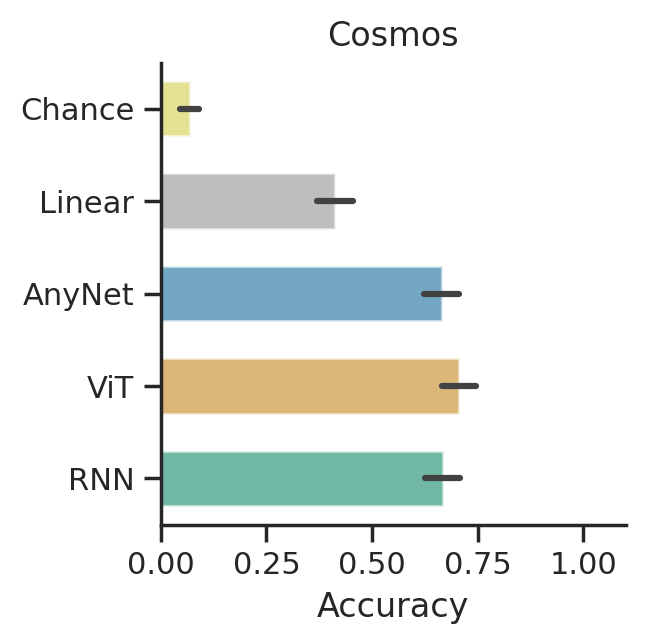

In [16]:
sns.set_theme(style='ticks')

plt.figure(figsize=(3, 3), dpi=200)
g = sns.barplot(
    data=acu,
    x='acu_test', y='model_type',
    errorbar='sd', width=0.6, palette=color_list_define, alpha=.6
)
plt.xlim([0, 1.1])
plt.ylabel('')
plt.xlabel('Accuracy')
sns.despine()
plt.title(f'Cosmos')

In [17]:
################################################################################
import subprocess
import sys
required = {'ONE-api', 'brain', 'ibllib'}
subprocess.check_call([sys.executable, '-m', 'pip', 'install', *required])

from one.api import ONE
from brainbox.io.one import SessionLoader, SpikeSortingLoader
from ibllib.atlas import AllenAtlas
from brainbox.io.spikeglx import Streamer
from neurodsp.voltage import destripe
from datetime import datetime
from pprint import pprint

ba = AllenAtlas()
br = ba.regions
ba.compute_regions_volume()


/usr/local/lib/python3.10/dist-packages/ibllib/atlas/__init__.py:205: DeprecationWarning: ibllib.atlas is deprecated. Please install iblatlas using "pip install iblatlas" and use this module instead
  warnings.warn('ibllib.atlas is deprecated. Please install iblatlas using "pip install iblatlas" and use '
/usr/local/lib/python3.10/dist-packages/neurodsp/__init__.py:5: FutureWarning: neurodsp has been renamed to ibldsp and the old name will be deprecated on 01-Sep-2024.
  warn(
/usr/local/lib/python3.10/dist-packages/ibllib/atlas/atlas.py:13: DeprecationWarning: ibllib.atlas.atlas.AllenAtlas is deprecated. Use iblatlas.atlas.AllenAtlas instead
  warnings.warn(warning_text, DeprecationWarning)


Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/histology/ATLAS/Needles/Allen/average_template_25.nrrd Bytes: 32998960


100%|██████████| 31.470260620117188/31.470260620117188 [00:31<00:00,  1.01s/it]


Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/histology/ATLAS/Needles/Allen/annotation_25.nrrd Bytes: 4035363


100%|██████████| 3.848422050476074/3.848422050476074 [00:02<00:00,  1.69it/s]


In [18]:
cosmos_indices = np.unique(br.mappings['Cosmos'])
acronym_list_Cosmos = [acronym for acronym in br.acronym[cosmos_indices] if acronym != 'void' and acronym != 'root']
print(acronym_list_Cosmos)

['Isocortex', 'OLF', 'HPF', 'CTXsp', 'CNU', 'TH', 'HY', 'MB', 'HB', 'CB']


In [19]:
np.argwhere(np.array(list_dict['brain_region_index_Cosmos']) == 1).flatten()

array([ 865018,  865019,  865020, ..., 2663959, 2663960, 2663961])

In [20]:
Classifier_name = ['AnyNet', 'ViT', 'RNN']
Classifier_list = [Classifier_AnyNet, Classifier_ViT, Classifier_RNN]
acu_test = []
acronym_test = []
model_name = []
for Classifier_ii, Classifier in enumerate(Classifier_list):
    for acronym_ii, acronym in enumerate(acronym_list_Cosmos):

        test_ind_acronym_ii = np.intersect1d(np.argwhere(np.array(list_dict['brain_region_index_Cosmos']) == acronym_ii).flatten(), test_ind)

        if len(test_ind_acronym_ii) < 1:
            # print(acronym)
            continue
        else:

            test_indiv = test_ind_acronym_ii
            data_test_indiv = TensorDataset(brain_signal_lfp[test_indiv,:], brain_region_index_Cosmos[test_indiv])
            test_iter_indiv = DataLoader(data_test_indiv, batch_size=128, shuffle=True)

            for x_test1, y_test in test_iter_indiv:

                x_test = lfp_spectro(x_test1, spectro_args, train_args)
                y_test = y_test.to(device)


                if Classifier_name[Classifier_ii] == 'RNN':
                    py_test = Classifier(x_test.to(device).squeeze(1).permute(0, 2, 1))
                elif Classifier_name[Classifier_ii] in ['Chance', 'Linear']:
                    py_test = Classifier(x_test.to(device).squeeze(1).flatten(start_dim=1))
                else:
                    py_test = Classifier(x_test.to(device))

                # print(acronym, f'acu: {(torch.sum(torch.argmax(py_test, dim=1) == y_test) / y_test.size(0)).detach().cpu()}')
                acronym_test.append(acronym)

                acu_test.append(accu_fun(py_test, y_test))

                model_name.append(Classifier_name[Classifier_ii])


acu_test = pd.DataFrame({
    'acu_test': np.array(acu_test),
    'model_type': model_name,
    'acronym_test': acronym_test,
})


<ipython-input-72-e6864c4bde03>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


<Figure size 1200x400 with 0 Axes>

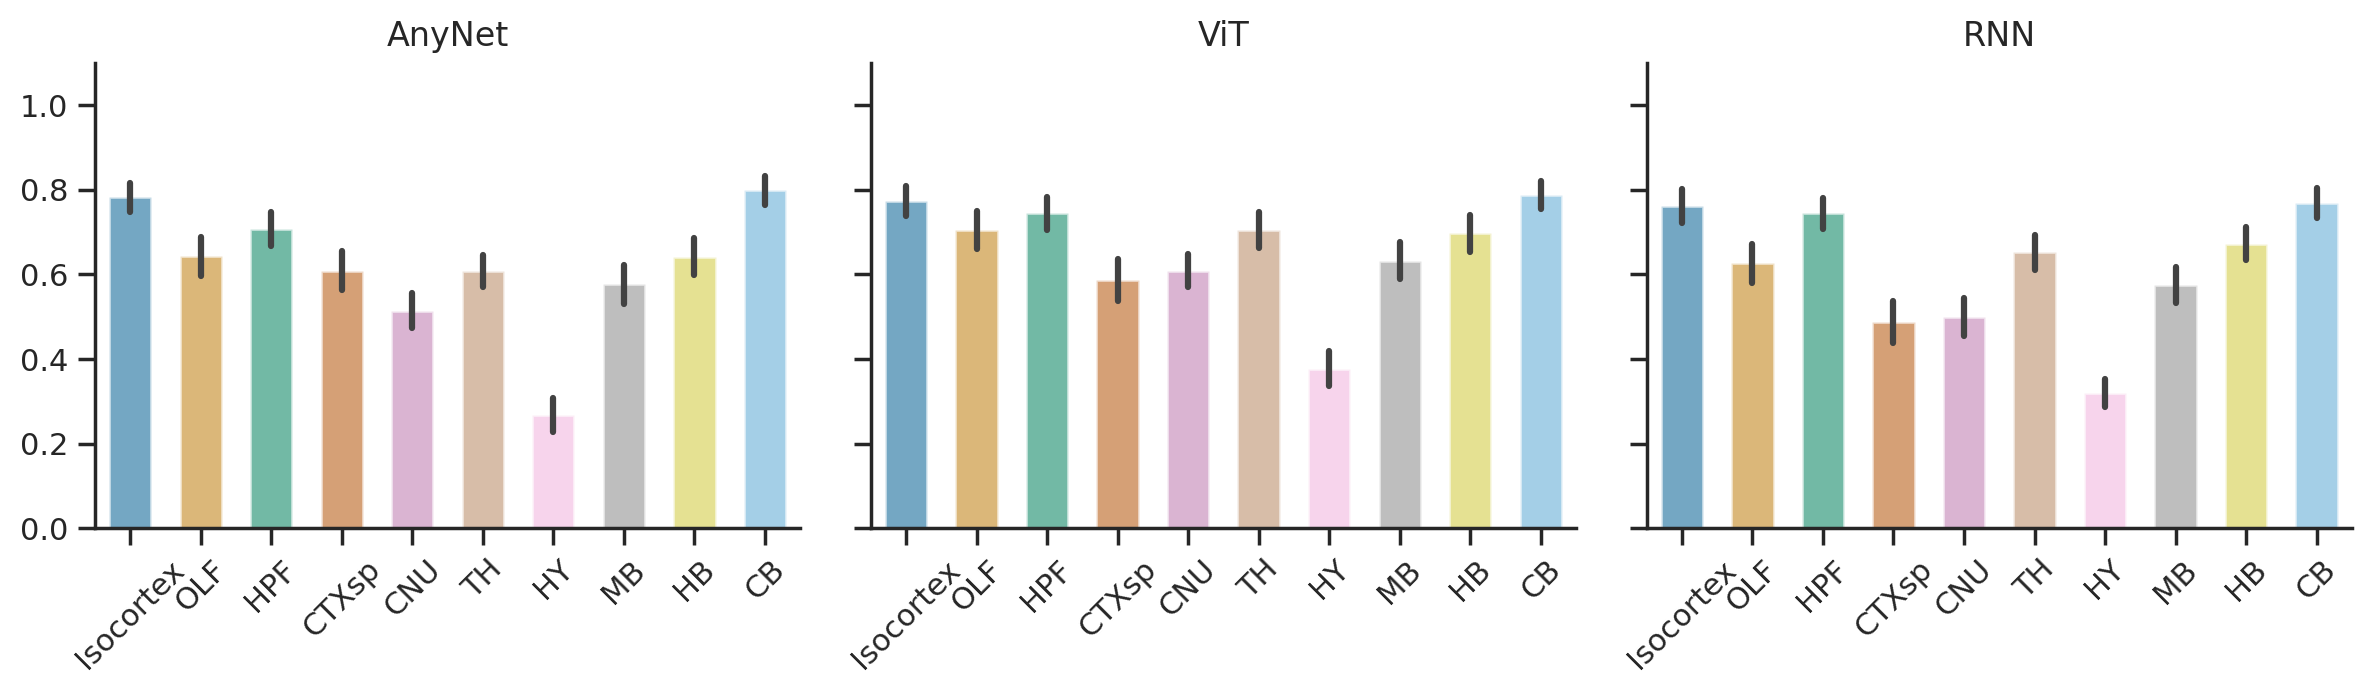

In [72]:
# sns.set_theme(style='ticks')
# plt.figure(figsize=(6, 2), dpi=200)
# g = sns.catplot(
#     data=acu_test, kind='bar',
#     x='acronym_test', y='acu_test', col='model_type',
#     errorbar='sd', width=0.6, palette='colorblind', alpha=0.6, height=3.4, aspect=1.2
# )
# g.set(ylim=[0, 1.1])
# g.set(xlabel='')
# g.set(ylabel='')
# g.tick_params(axis='x', rotation=45)
# g.set_titles('{col_name}')

In [ ]:
from google.colab import runtime
runtime.unassign()